# Baseline Model (TF-IDF)


# Setup

In [ ]:
import datasets
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from google.colab import drive, userdata
from huggingface_hub import login, hf_hub_download

cache_path = "/content/huggingface_cache"
os.makedirs(cache_path, exist_ok=True)
os.environ['HF_HOME'] = cache_path

if userdata.get('HF_TOKEN'):
  login(token=userdata.get('HF_TOKEN'))
  hf_hub_download(repo_id="sookiemonster/asrs-narratives", filename="utils.py", repo_type="dataset",local_dir=".")
  hf_hub_download(repo_id="sookiemonster/asrs-narratives", filename="all_contributing_factors.csv", repo_type="dataset",local_dir=".")

raw_dataset = datasets.load_dataset("sookiemonster/asrs-narratives")
factors = pd.read_csv("all_contributing_factors.csv", index_col=0)

In [ ]:
train_ds = datasets.load_dataset("sookiemonster/asrs-narratives-rebalance", split='train')
valid_ds = raw_dataset['validation']
test_ds = raw_dataset['test']

labels = train_ds.features['label'].names

id_to_label = { idx : label for idx, label in enumerate(labels) }
label_to_id = { label : idx for idx, label in id_to_label.items() }

In [ ]:
from functools import partial

def filter_labels(ds, to_remove:list):
  to_remove_set = set(to_remove)
  return ds.filter(lambda example : id_to_label[example['label']] not in to_remove_set)

filter_ambiguous = partial(filter_labels, to_remove=['ambiguous'])

filtered_train_ds = filter_ambiguous(train_ds)
filtered_valid_ds = filter_ambiguous(valid_ds)
filtered_test_ds = filter_ambiguous(test_ds)

In [ ]:
def _validate_groupings(groupings:dict[str, set]):
  mut_excl = [va.isdisjoint(vb) for ka, va in groupings.items() for kb, vb in groupings.items() if ka != kb]
  assert all(mut_excl), f"{mut_excl}"

  all_labels = set([label for val_set in groupings.values() for label in val_set])
  assert all_labels == set(id_to_label.values()), f"Missing: {set(id_to_label.values()) - all_labels}"


def group_labels(ds, groupings:dict[str, set]):
  _validate_groupings(groupings)
  group_names = list(groupings.keys())
  group_names.sort()

  fine_grained_label_to_group = {
      label : group_name for group_name, val_set in groupings.items() for label in val_set
  }

  res = ds.map(lambda ex: {"group" : fine_grained_label_to_group[ id_to_label[ex['label']] ]})
  res = res.filter(lambda ex: ex["group"] != 'DELETE')

  new_features = res.features.copy()
  group_names.remove("DELETE")
  new_features["group"] = ClassLabel(names=group_names)

  res = res.cast(new_features)
  return res

In [ ]:
def get_inv_class_weights(ds, labels, filter_by='group'):
  counts = ds.to_pandas()[filter_by].value_counts().to_dict()

  weights = {
      label : len(ds) / (len(labels) * counts[i]) for i, label in enumerate(labels) if counts.get(i, 0) > 0
  }

  tot = sum(weights.values())
  norm =  {
      k: round(v / tot, 4) for k,v in weights.items()
  }

  return norm

## Setup Dataset


In [ ]:
from datasets import ClassLabel

groupings = {
    'DELETE' : set(['ambiguous']),
}

groupings = groupings | {
    label : set([label]) for label in id_to_label.values() if label != 'ambiguous'
}

grouped_ds_train = group_labels(filtered_train_ds, groupings)
grouped_ds_valid = group_labels(filtered_valid_ds, groupings)
grouped_ds_test = group_labels(filtered_test_ds, groupings)

Map:   0%|          | 0/9072 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9072 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/9072 [00:00<?, ? examples/s]

In [ ]:
id_to_group = { i: group for i, group in enumerate(grouped_ds_train.features['group'].names) }
id_to_group

{0: 'aircraft',
 1: 'airport',
 2: 'airspacestructure',
 3: 'atcequipment/navfacility/buildings',
 4: 'chartorpublication',
 5: 'companypolicy',
 6: 'environment-nonweatherrelated',
 7: 'equipment/tooling',
 8: 'humanfactors',
 9: 'incorrect/notinstalled/unavailablepart',
 10: 'logbookentry',
 11: 'manuals',
 12: 'mel',
 13: 'procedure',
 14: 'softwareandautomation',
 15: 'staffing',
 16: 'weather'}

# Classifier & Evaluation

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

TF = TfidfVectorizer(min_df=10)

In [ ]:
def split_set(ds):
  full = ds.to_pandas().set_index('acn')
  full = full.drop('label', axis=1)
  full.group = full.group.map(id_to_group)

  X = full['text']
  y = full['group']
  return X, y

X_train, y_train = split_set(grouped_ds_train)
X_valid, y_valid = split_set(grouped_ds_valid)
X_test, y_test = split_set(grouped_ds_test)

## Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

est = MultinomialNB()
mdl = make_pipeline(TF, est)

In [ ]:
mdl.fit(X_train, y_train)

Pipeline(steps=[('tfidfvectorizer', TfidfVectorizer(min_df=10)),
                ('multinomialnb', MultinomialNB())])

In [ ]:
y_pred = mdl.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                                        precision    recall  f1-score   support

                              aircraft       0.81      0.86      0.83      3122
                               airport       0.00      0.00      0.00         0
                     airspacestructure       0.00      0.00      0.00         0
    atcequipment/navfacility/buildings       0.00      0.00      0.00         0
                    chartorpublication       0.06      0.89      0.11         9
                         companypolicy       0.06      0.16      0.08        19
         environment-nonweatherrelated       0.02      0.56      0.04         9
                     equipment/tooling       0.00      0.00      0.00         0
                          humanfactors       0.76      0.64      0.70      3973
incorrect/notinstalled/unavailablepart       0.00      0.00      0.00         0
                          logbookentry       0.00      0.00      0.00         0
                               manuals 

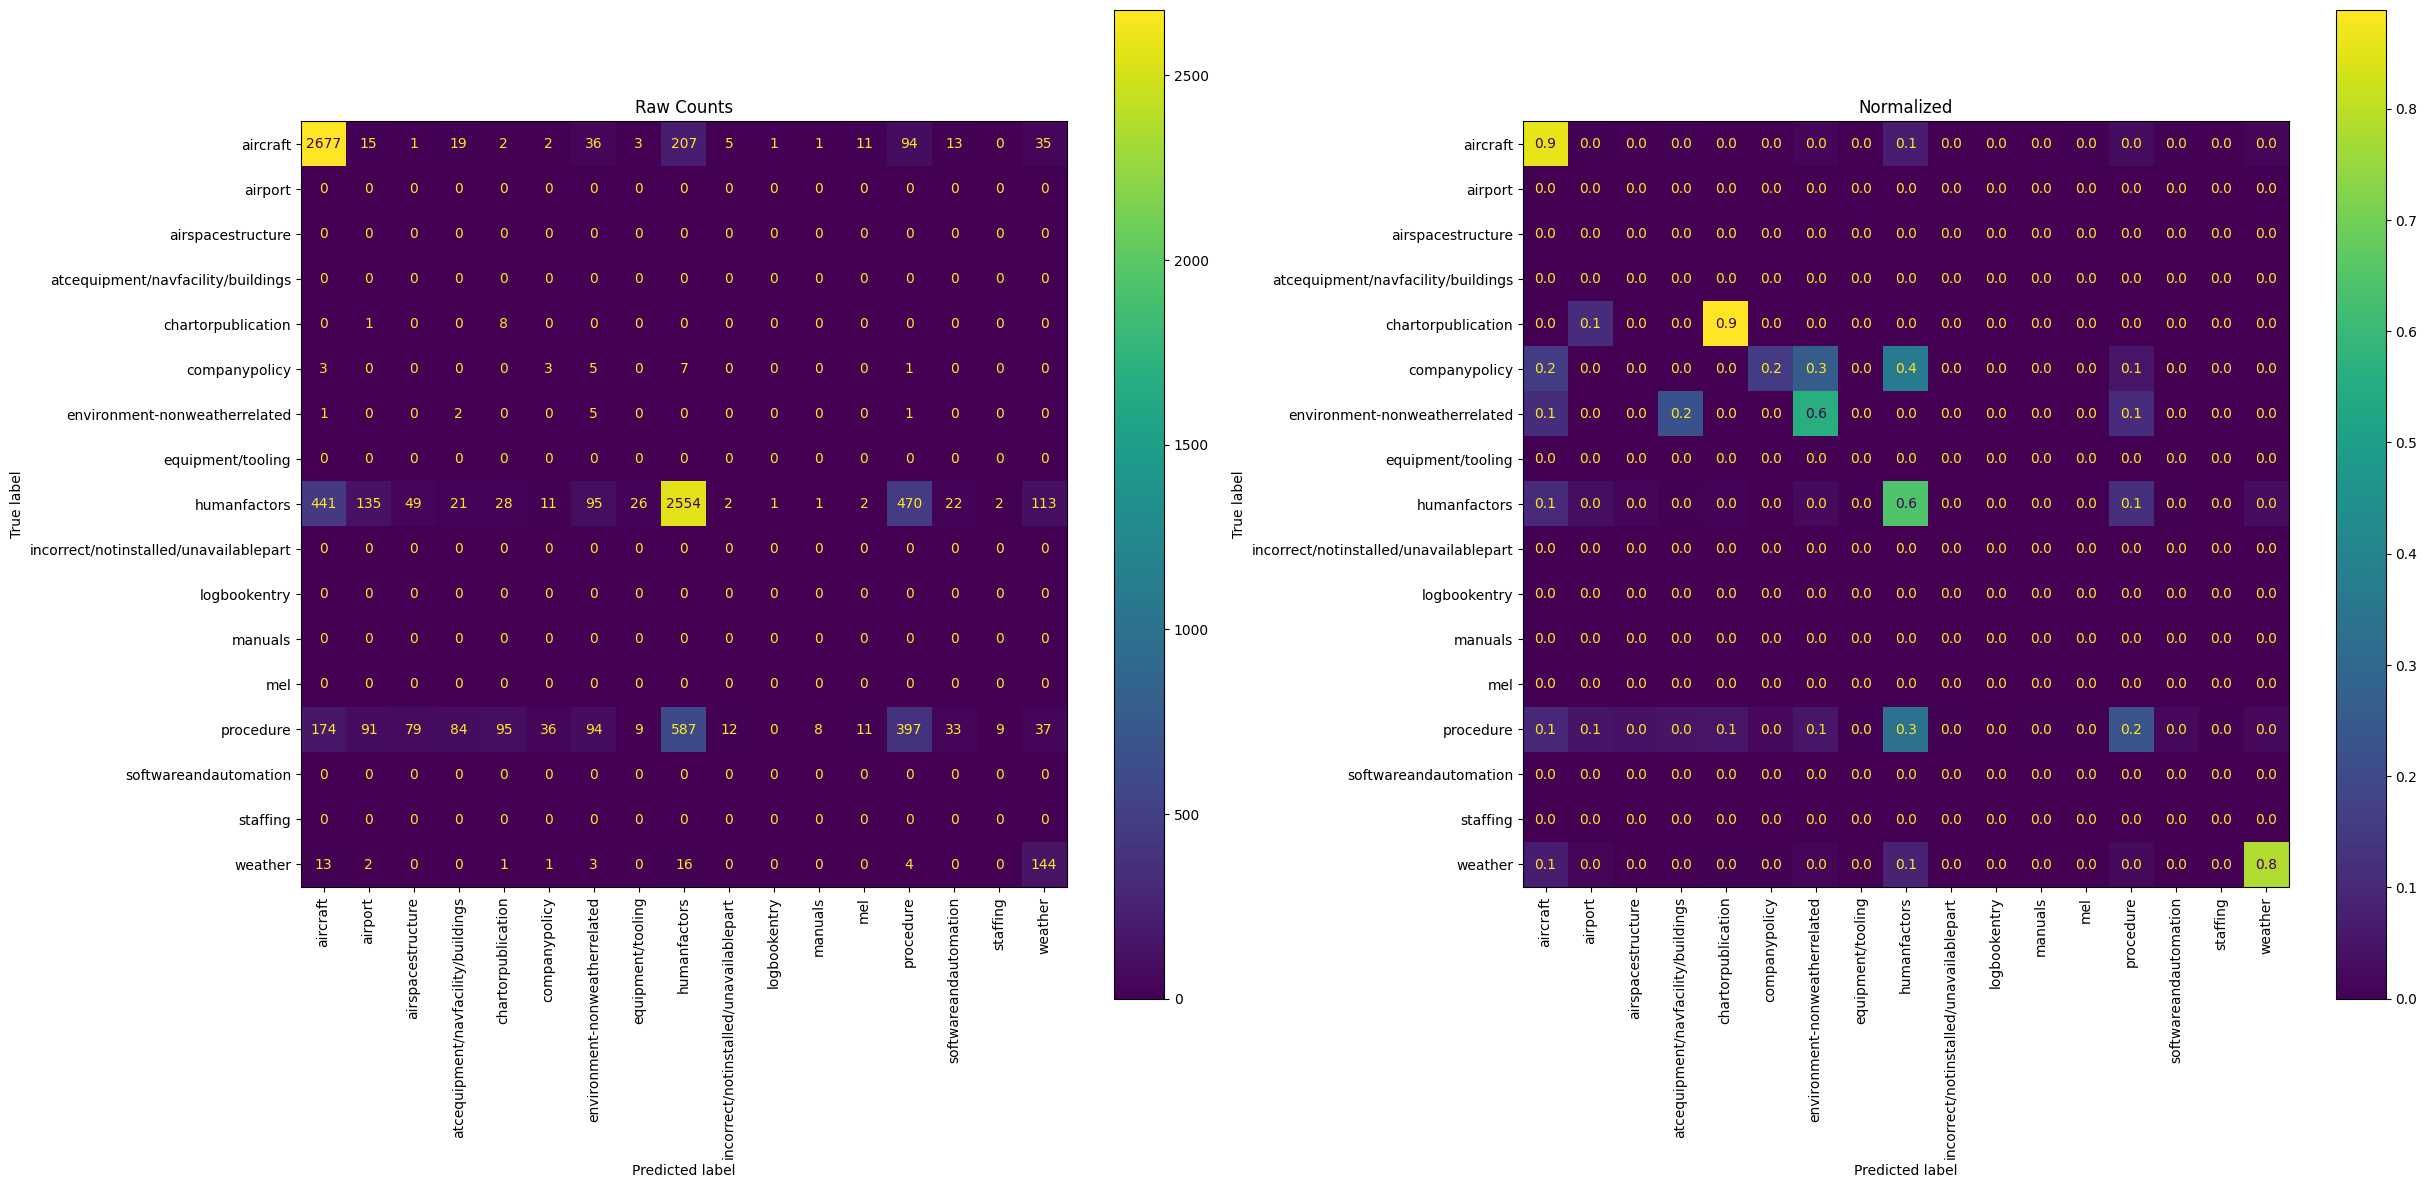

In [ ]:
from utils import visualize_eval

visualize_eval(y_pred, y_test, label="TF-IDF + Naive Bayes")

## Logistic Regression


In [ ]:
from sklearn.linear_model import LogisticRegression

est = LogisticRegression(solver='saga', random_state=42)
mdl = make_pipeline(TF, est)
mdl.fit(X_train, y_train)
y_pred = mdl.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                                        precision    recall  f1-score   support

                              aircraft       0.82      0.88      0.85      3063
                               airport       0.17      0.80      0.28        51
                     airspacestructure       0.19      0.57      0.29        44
    atcequipment/navfacility/buildings       0.26      0.49      0.34        67
                    chartorpublication       0.49      0.57      0.53       115
                         companypolicy       0.17      0.10      0.13        89
         environment-nonweatherrelated       0.20      0.36      0.25       132
                     equipment/tooling       0.03      0.50      0.05         2
                          humanfactors       0.72      0.68      0.70      3558
incorrect/notinstalled/unavailablepart       0.00      0.00      0.00         0
                          logbookentry       0.00      0.00      0.00         0
                               manuals 

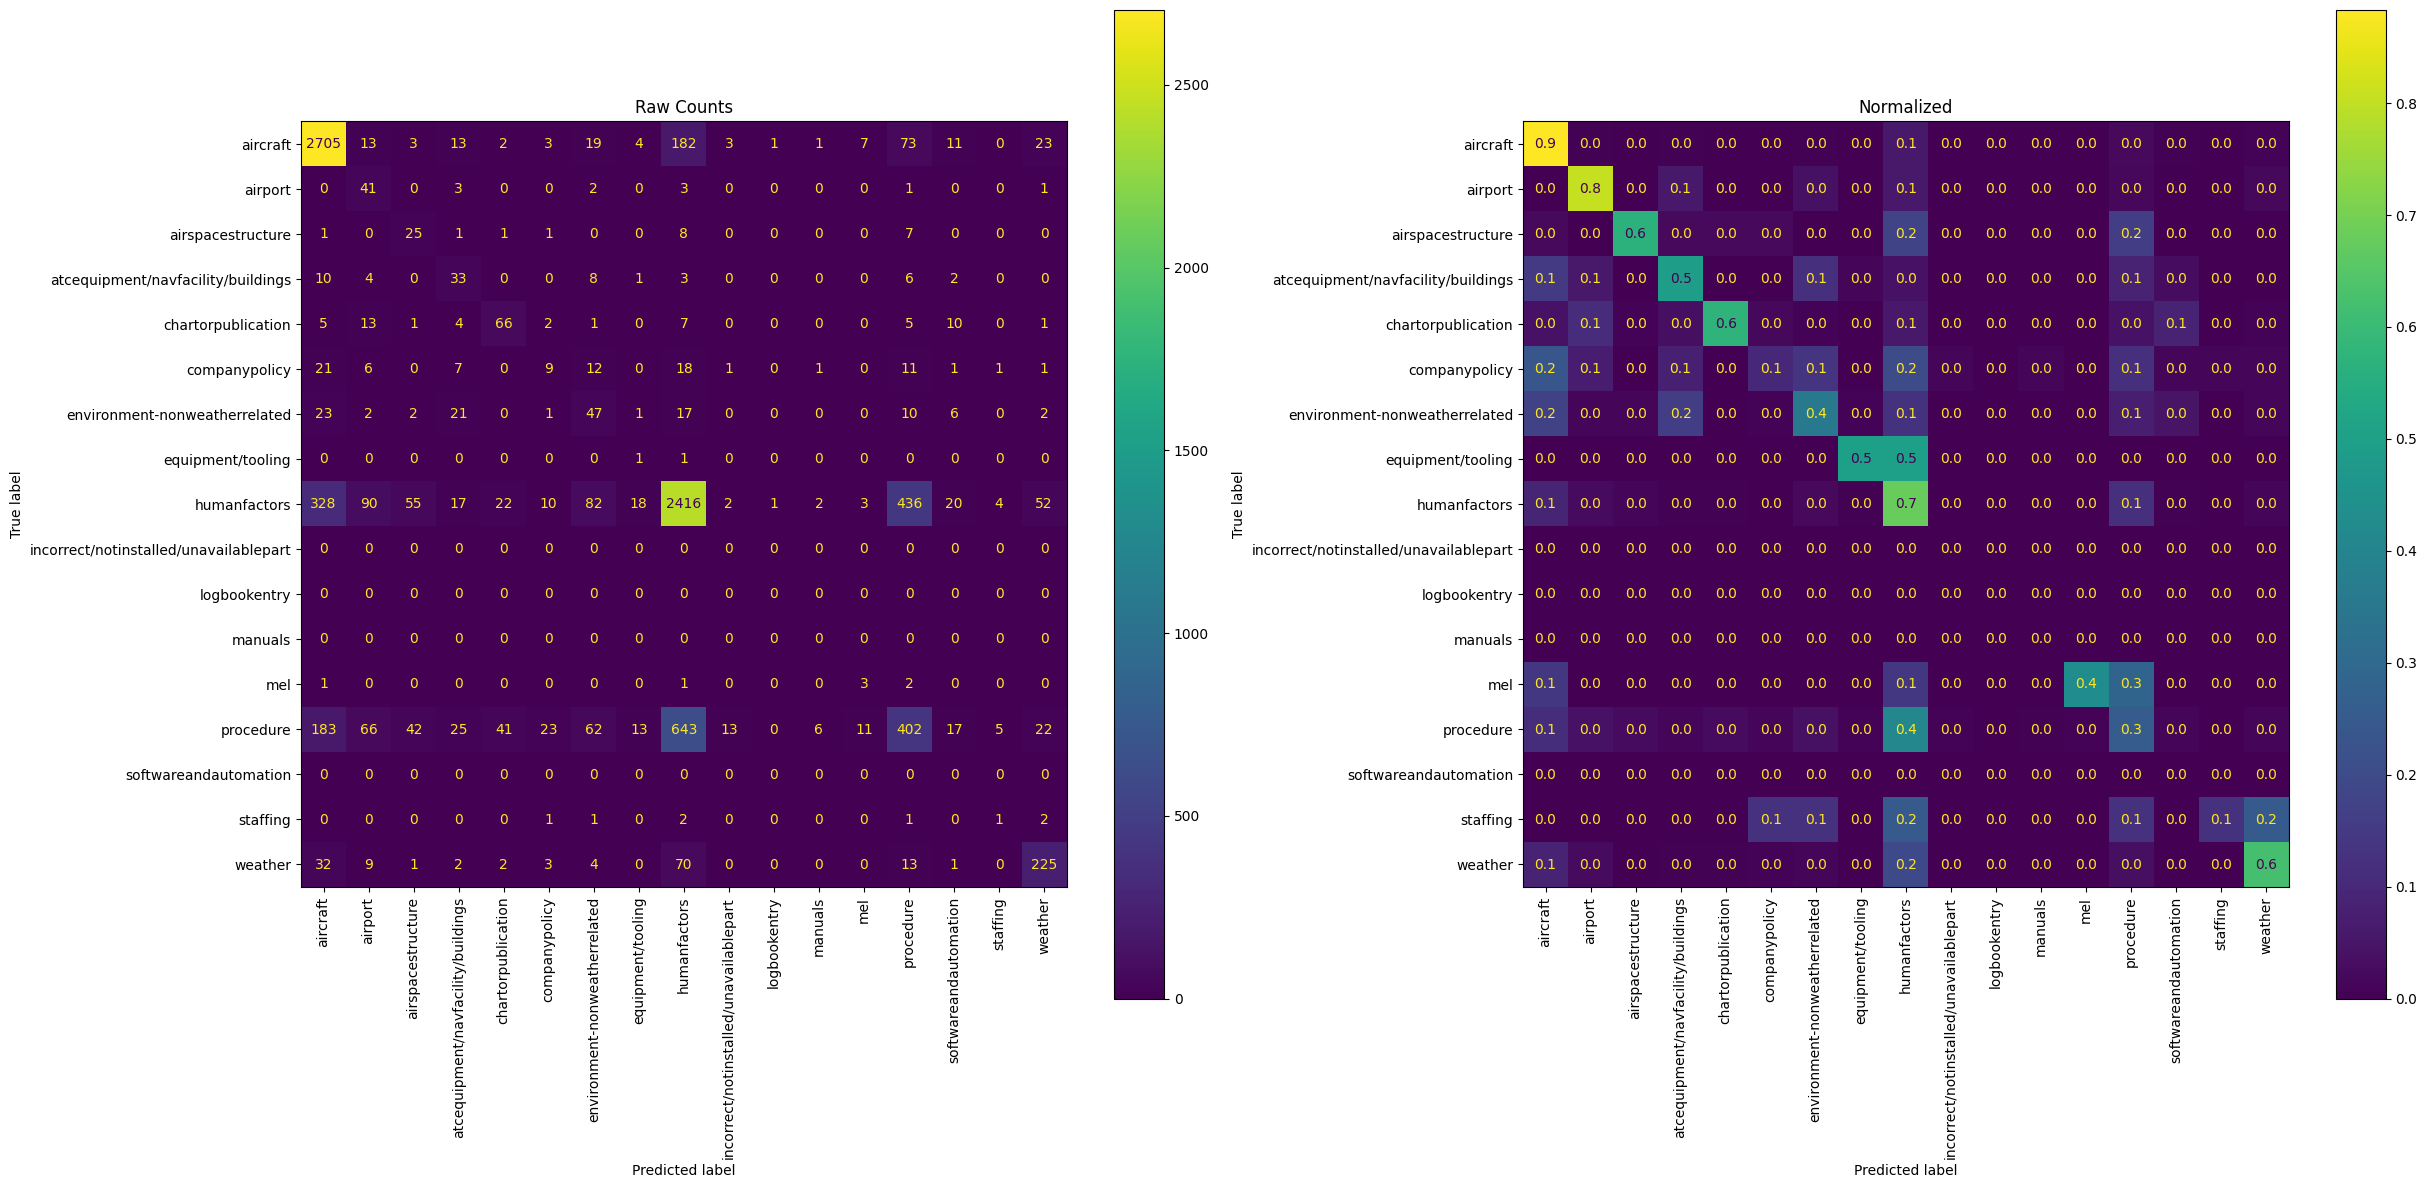

In [ ]:
from utils import visualize_eval

visualize_eval(y_pred, y_test, label="TF-IDF + Naive Bayes")